In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [16]:
df = pd.read_csv("Zomato-data-.csv")
df.columns = df.columns.str.strip()

In [5]:
df.columns = df.columns.str.strip()

In [17]:
# Clean cost
df["approx_cost(for two people)"] = df["approx_cost(for two people)"].astype(str)
df["approx_cost(for two people)"] = df["approx_cost(for two people)"].str.replace(",", "")
df["approx_cost(for two people)"] = pd.to_numeric(
    df["approx_cost(for two people)"], errors="coerce"
)

In [18]:
# Clean rate
df["rate"] = df["rate"].astype(str).str.split("/").str[0]
df["rate"] = pd.to_numeric(df["rate"], errors="coerce")


In [19]:
# Drop NaNs
df = df.dropna(subset=["approx_cost(for two people)", "rate", "votes"])
# Drop NaNs
df = df.dropna(subset=["approx_cost(for two people)", "rate", "votes"])


In [9]:
features = ["rate", "votes"]

X = df[features]
y = df["approx_cost(for two people)"]

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [20]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

In [21]:
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

In [22]:
print("Linear Regression:")
print("RMSE:", rmse_lr)
print("R2 Score:", r2_lr)

print("\nRandom Forest:")
print("RMSE:", rmse_rf)
print("R2 Score:", r2_rf)

Linear Regression:
RMSE: 200.84427401711983
R2 Score: 0.011043852767160911

Random Forest:
RMSE: 207.71717237775002
R2 Score: -0.057798456293846945


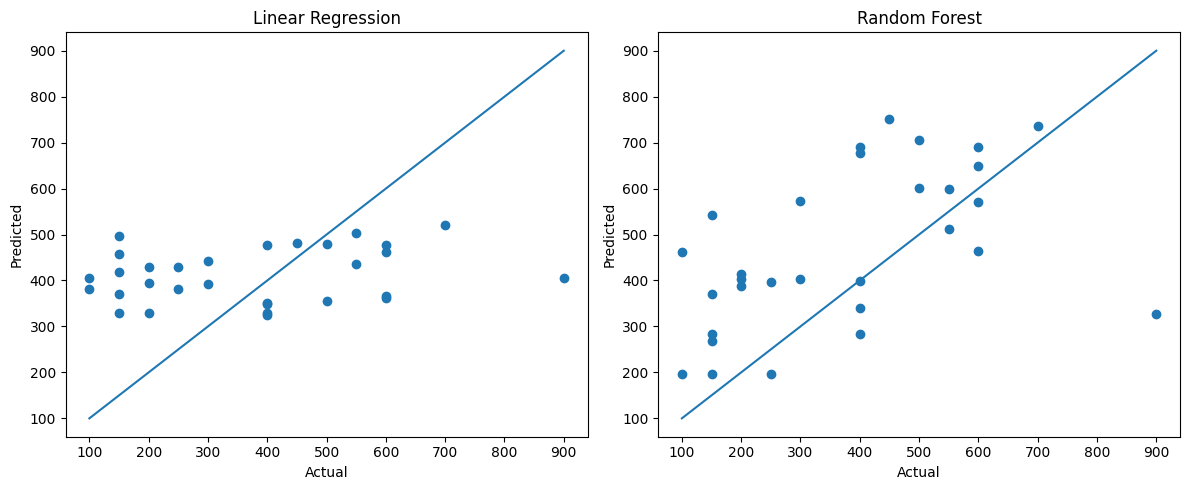

In [23]:
plt.figure(figsize=(12, 5))

# Linear Regression Plot
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_lr)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])
plt.title("Linear Regression")
plt.xlabel("Actual")
plt.ylabel("Predicted")

# Random Forest Plot
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_rf)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])
plt.title("Random Forest")
plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.tight_layout()
plt.show()